##Syllabus Machine Learning II

**Week 12: Dimensionality reduction**

*   Principal component analysis (PCA)

In [1]:
# Mount Drive files
from google.colab import drive
import sys, os

# Uncomment for mounting drive files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 9/utils.py" /content
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 9/data" /content/data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display, clear_output
import zipfile

# Sklearn auxiliary items
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from utils import (
    scatter_with_line,
    project_points_onto_line,
    orthogonal_distances_cost_function,
    visualize_unit_vector,
    rotate_points,
    plot_2d_with_classes
)

# Matplotlib Options
plt.rcParams['figure.figsize'] = [16, 8]
font = {'weight' : 'bold',
        'size'   : 14}
plt.rc('font', **font)

# Pandas options
pd.set_option("display.max_columns", 100)

# Hide warnings in Notebook
import warnings
warnings.filterwarnings('ignore')

# Principal Component Analysis - Walkthrough

**Principal Component Analysis (PCA) is a pre-processing technique that is commonly used in machine learning and statistics to reduce the number of features in a dataset while retaining as much information as possible.**

The goal of PCA is to transform the original set of variables into a new set of linearly uncorrelated variables, called principal components (PCs), which can be used to explain the variance in the original dataset.

Let's look at the following dataset that we will load using `pd.read_csv` with information about people's salary - using a sample of 5 people first:

In [3]:
salary_data = pd.read_csv('/content/data/Salary Data.csv', sep=';').sample(5, random_state=49)

In [4]:
salary_data.head()

,Person,Monthly Salary,Age,Education Level
16,R,4000,20,3
11,M,15846,40,3
22,Z,20000,50,4
7,H,2000,26,1
21,X,2500,45,1


Let's plot Monthly Salary vs. Age in a 2D scatter plot:

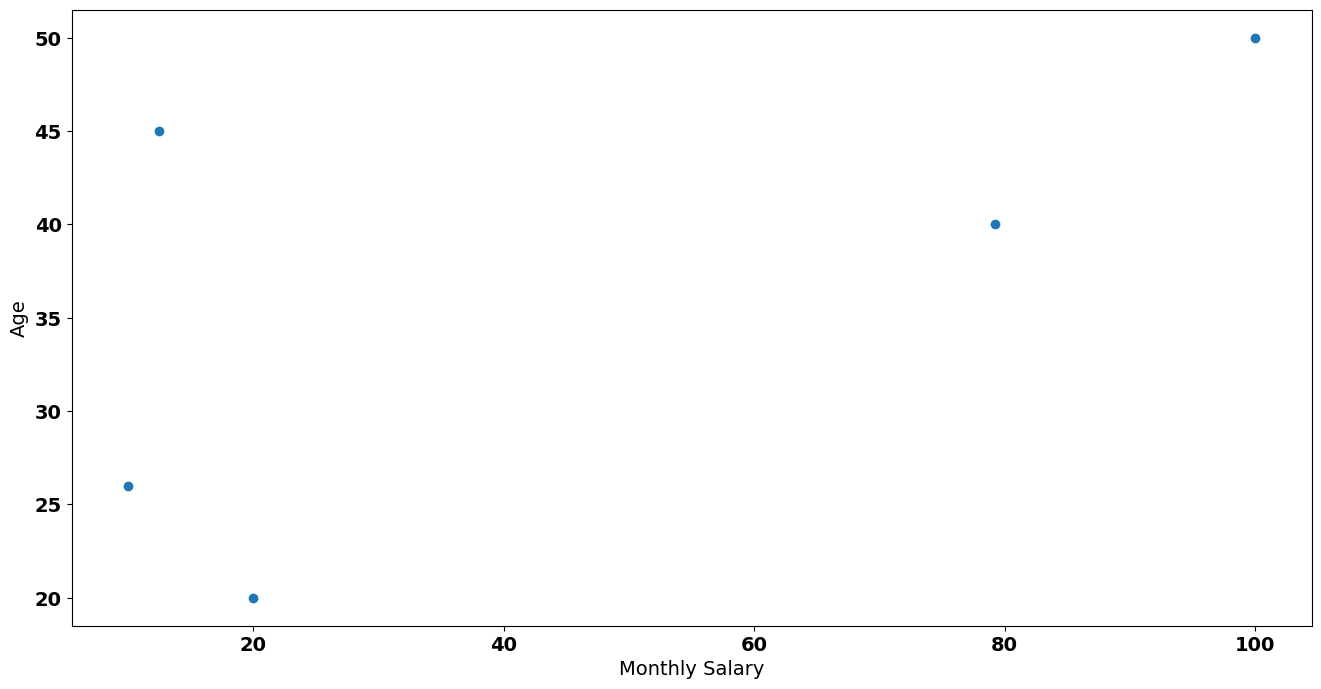

In [5]:
# Scalling monthly salary to avoid standard-scalling the
# variables during the explanation
# Standard scalling would bring the slope
# of the PC to 1 and it would
# make it harder to explain the ratio of influence of the variables.

plt.scatter(
    salary_data['Monthly Salary']*0.005,
    salary_data.Age
)

plt.ylabel('Age')
plt.xlabel('Monthly Salary')
plt.show()

Notice that there is a positive correlation between these two variables. We can measure that by using `corr`:

In [6]:
salary_data[['Monthly Salary','Age']].corr()

,Monthly Salary,Age
Monthly Salary,1.000000,0.635985
Age,0.635985,1.000000


One of the main ideas behind principal component analysis is that we can represent different variables in a single "component" given some weights.
<br>
<br>
For example, with this example, knowing the `age` would be enough to, roughly, know the salary of someone.

In [7]:
# Scalling monthly Salary just to be on an approximate "scale"
salary_data['Monthly Salary'] = salary_data['Monthly Salary']*0.005

# First step is to center everything on the origin.
salary_data['Monthly Salary'] -= salary_data['Monthly Salary'].mean()
salary_data['Age'] -= salary_data['Age'].mean()

**1st Step of PCA:** Center data on the origin!

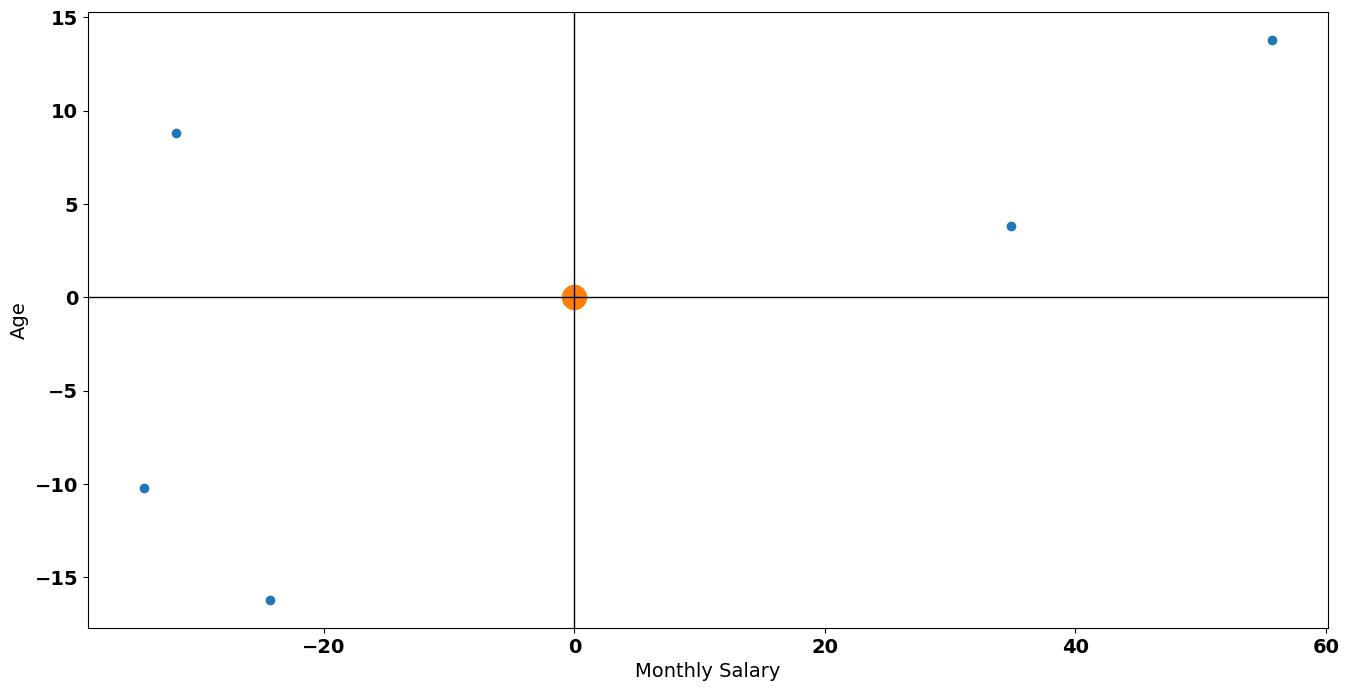

In [8]:
plt.scatter(
    salary_data['Monthly Salary'],
    salary_data.Age
)

plt.scatter(
    salary_data['Monthly Salary'].mean(),
    salary_data.Age.mean(),
    s=300
)


plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.ylabel('Age')
plt.xlabel('Monthly Salary')
plt.show()

Now, let's throw a random line in the plot:

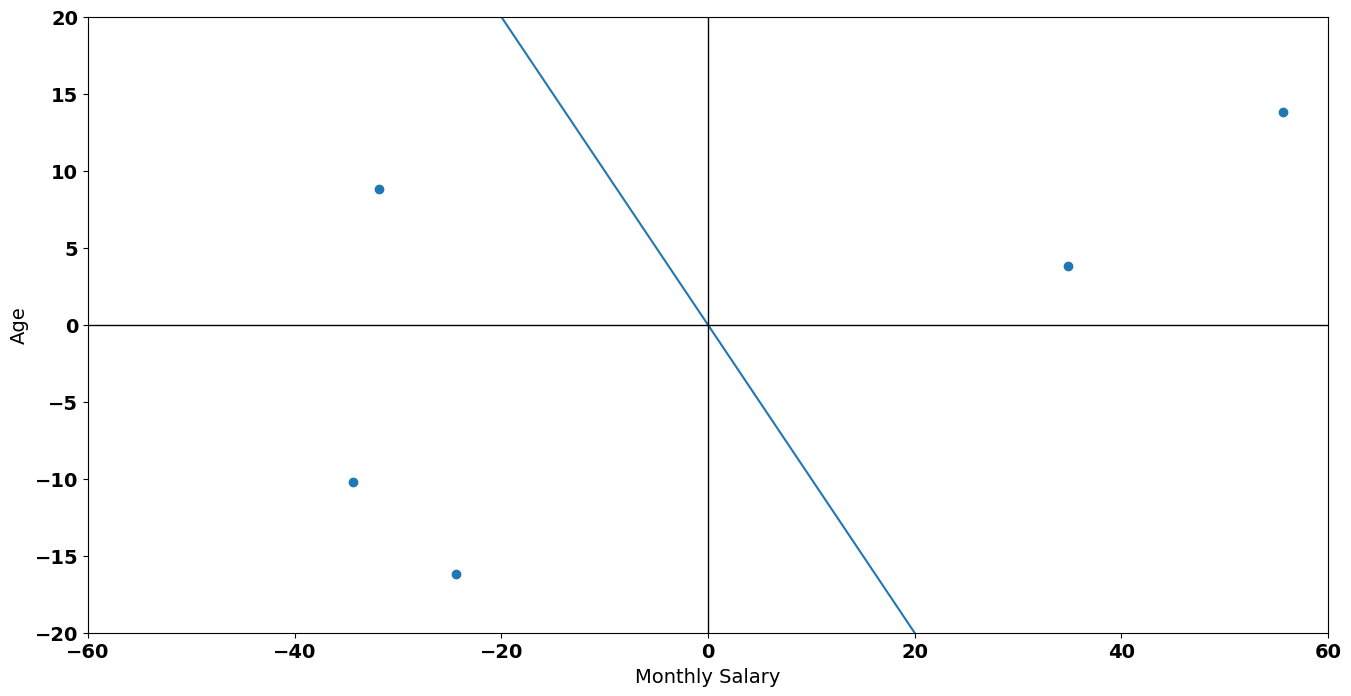

In [9]:
scatter_with_line(salary_data, -1)

Is this line capturing the variability of the data? Not quite! In the context of `PCA`, "capturing the variability" means that `PCA` wants to minimize the orthogonal distance between our points and the line. Let's first project our points onto the line we've just created:

In [10]:
salary_data

,Person,Monthly Salary,Age,Education Level
16,R,-24.346,-16.2,3
11,M,34.884,3.8,3
22,Z,55.654,13.8,4
7,H,-34.346,-10.2,1
21,X,-31.846,8.8,1


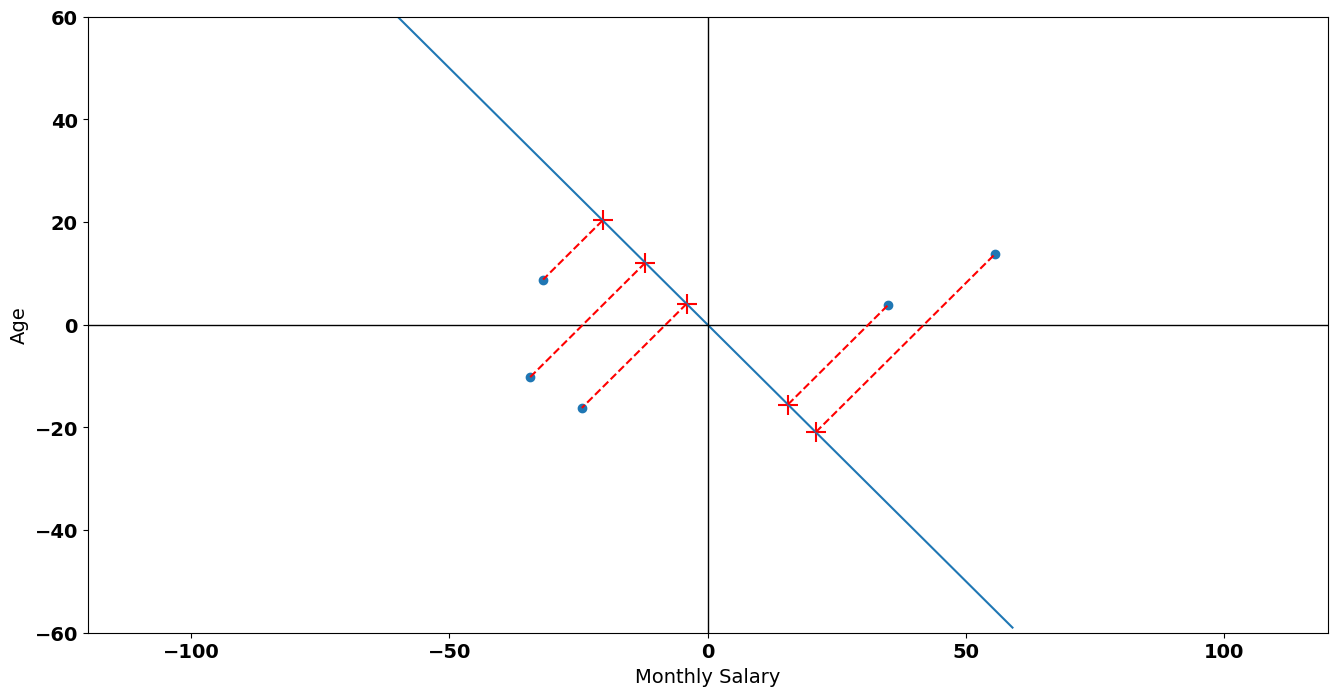

In [11]:
orthogonal_points = project_points_onto_line(salary_data, -1)

*Note: My `project_points_onto_line ` function is being a bit lazy - I'm using the function to both plot and return the orthogonal points. A best prectice would be to split this function into smaller chunks*

Here's a proof that this projection is the orthogonal projection of our data - for example, multiplying the slope of both lines (choosing a random point below), yields ~ `-1` - a proof for orthogonality!

In [12]:
orthogonal_point = [orthogonal_points[1,0], orthogonal_points[1,1]]

(
    (orthogonal_point[1]-salary_data.Age.iloc[1])
    /
  (orthogonal_point[0]-salary_data['Monthly Salary'].iloc[1])
)*-1


np.float64(-0.9999999999999997)

Now, if we calculate the sum of squared distances of the **orthogonal distances**, we get something:

In [13]:
sq_distance = 0

for i in range(len(orthogonal_points)):
    sq_distance += (
        (orthogonal_points[i,0]-salary_data.iloc[i,1])**2
        +
        (orthogonal_points[i,1]-salary_data.iloc[i,2])**2
    )

In [14]:
print('Our orthogonal squared distance is {}'.format(sq_distance))

Our orthogonal squared distance is 5239.87616


Is this line capturing the variability of the data? Not quite! **So, our goal is now to minimize the orthogonal distance!**

Here's a visual example:

FloatSlider(value=-0.7, description='Slope:', max=3.0, min=-3.0)

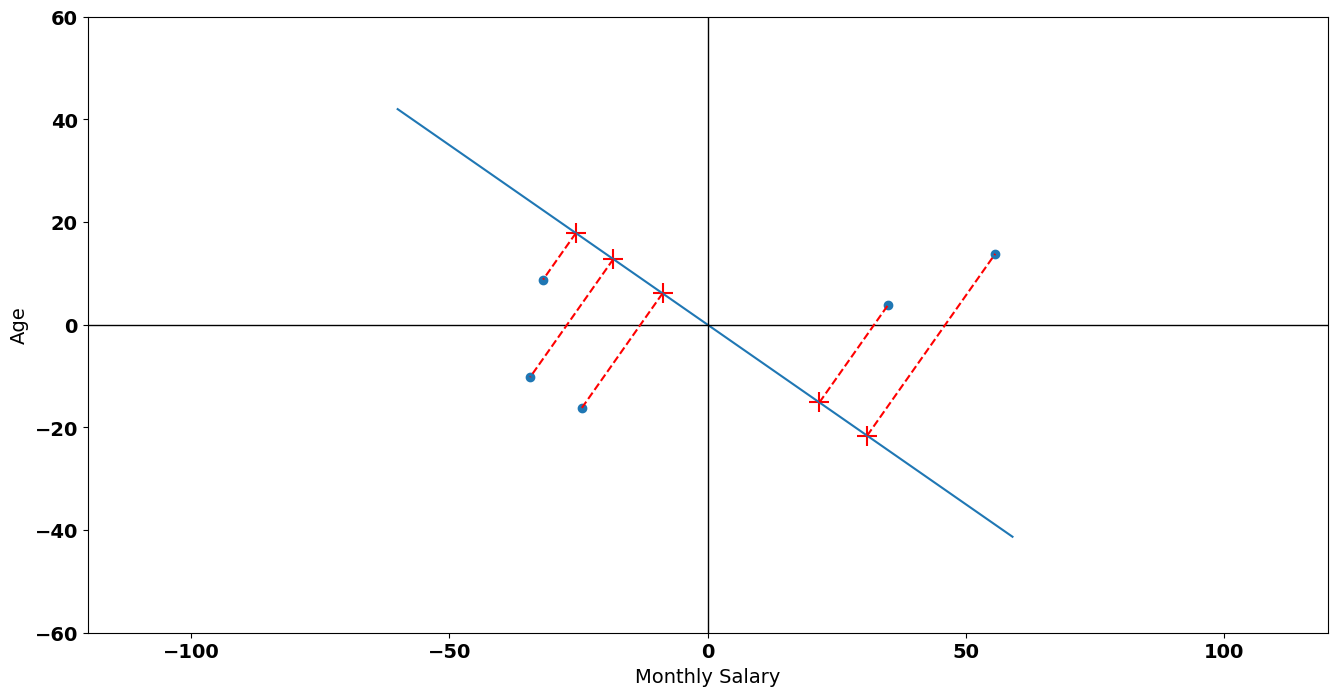

In [15]:
slope = widgets.FloatSlider(min=-3, max=3, value=1, description='Slope:')
display(slope)

def update_plot(change):
    clear_output(wait=True)
    display(slope)
    _ = project_points_onto_line(salary_data, change.new)

slope.observe(update_plot, names='value')

After some experiments, we discover that the line that minimizes our orthogonal distances has slope = `0.2`!
<br>
<br>
Note: Don't confuse this with linear regression - we are minimizing the orthogonal distance and not the typical "squared distance". More than filling this notebook with a detailed explanation, I'll use wisdom of the crowds and point you to this blog post explains that explains that concept very, very well: https://shankarmsy.github.io/posts/pca-vs-lr.html

Let's see, for example, the sum of orthogonal squared distances for all hypothetical slopes from `-10` to `10`:

In [16]:
slope_result = orthogonal_distances_cost_function(salary_data, -10, 10)

We can now plot a "kind of" cost function plot:

<Axes: >

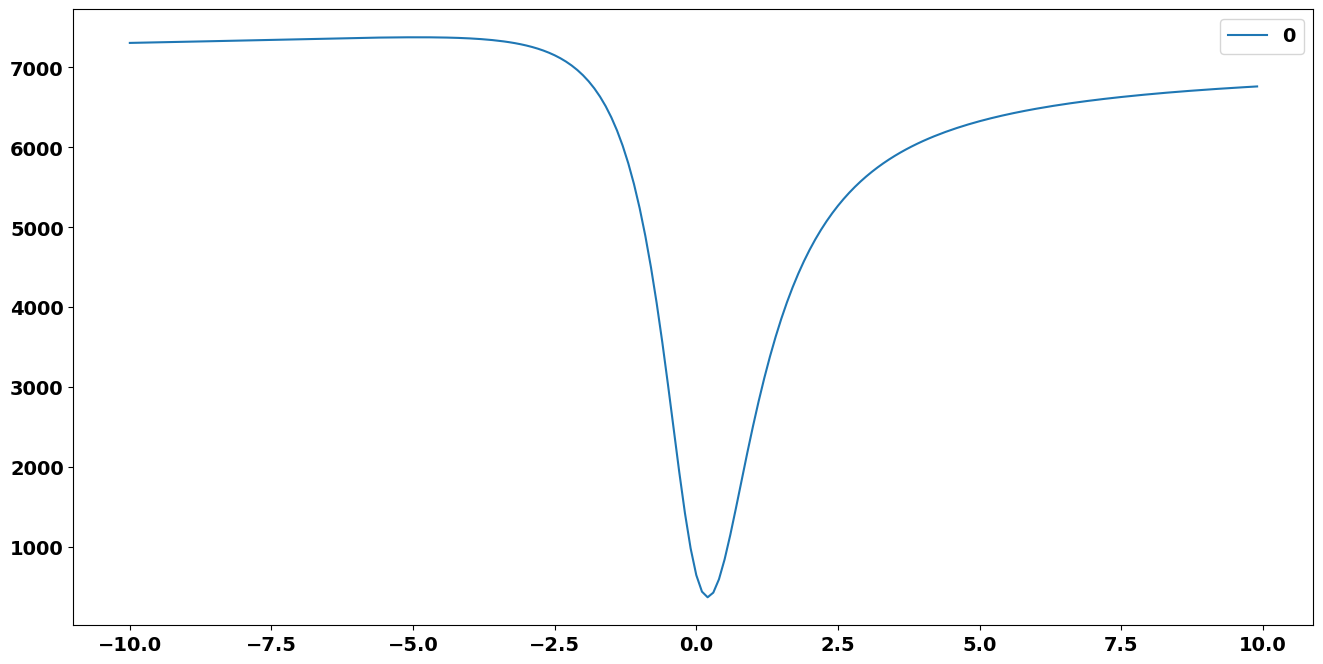

In [17]:
pd.DataFrame.from_dict(slope_result).T.plot()

**What's the point that minimizes the distances?**

In [18]:
pd.DataFrame.from_dict(slope_result).T.sort_values(by=0).head(1)

,0
0.2,371.925551


**Slope 0.2 is the lowest in our experiments!** Let's settle with that line and plot it:

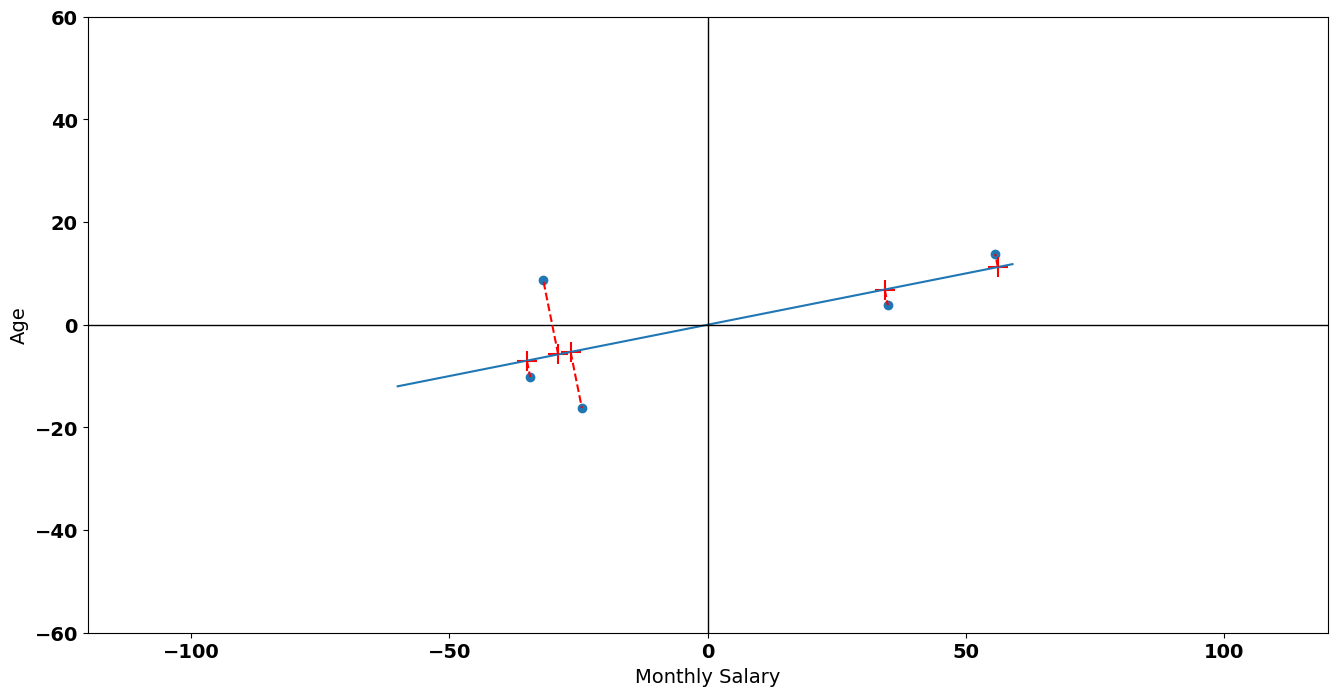

In [19]:
_ = project_points_onto_line(salary_data, 0.2)

What does 0.2 mean? Basically, if we have a slope of 0.2, our rise over run is equal to: for every 5 points we walk on the `x-axis`, we walk 1 on the `y`. **This means that the `x` variable is 5 times more powerful explaining the variability of the data!** - This sentence "5 times variable x vs. 1 time variable y" is what we normally hear as a "linear combination".

Now let me plot that line until point 5 over 1 (the ratio between the influence of the variables):

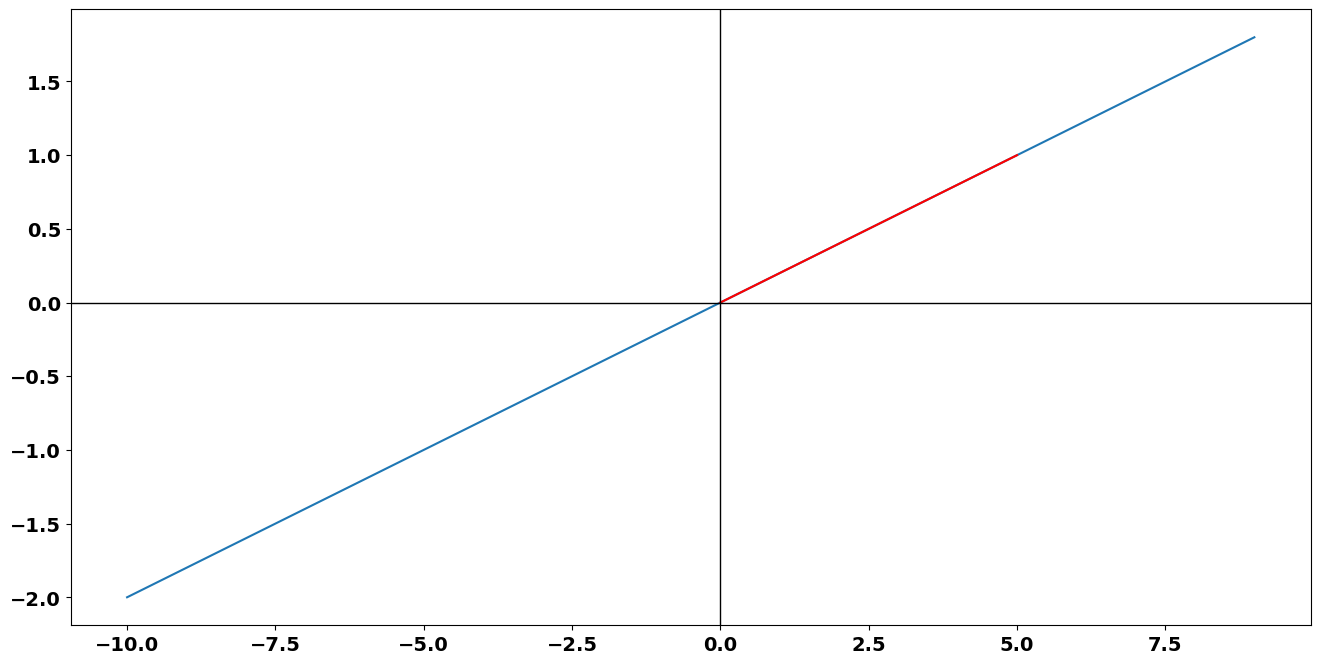

In [20]:
slope = 0.2

plt.plot(
    range(-10, 10),
    [i*slope for i in range(-10, 10)]
)

plt.plot(
    range(0, 6),
    [i*slope for i in range(0, 6)],
    color='red'
)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

I want to know the length of the red line:

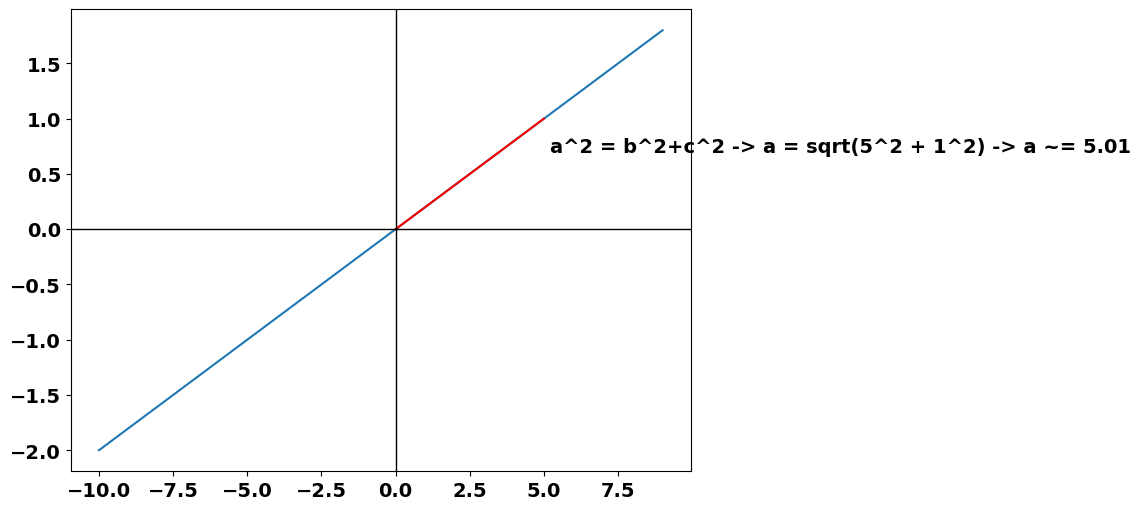

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

plt.plot(
    range(-10, 10),
    [i*slope for i in range(-10, 10)]
)

plt.plot(
    range(0, 6),
    [i*slope for i in range(0, 6)],
    color='red'
)

ax.annotate('a^2 = b^2+c^2 -> a = sqrt(5^2 + 1^2) -> a ~= 5.01', (5,1), (5.2, 0.7))

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

The length of the red line is 5.01 - we want to scale this so that the length of our red line is `1`. We can do that by dividing each part of the triangle by `5.01`:

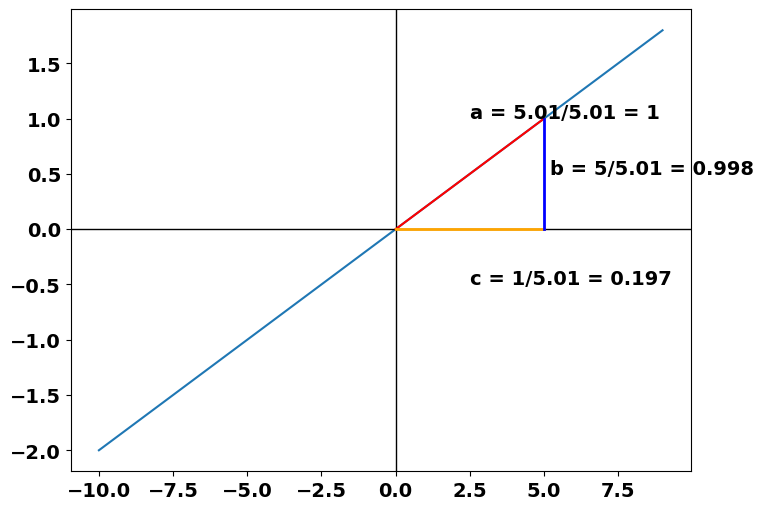

In [22]:
visualize_unit_vector(0.2)

The values of the relation 5-1 remain the same, we've just scaled them. Approximately, the ratio of 0.998/0.197 still encompass a relationship of 5-1 (within a small epsilon due to rounding elements).

You know what's that vector of norm (length) 1 that we've just discovered? A `singular vector` or `eigenvector` for `PC1`!
<br>
<br>
Also, the proportion of each variable are known as the `loading scores`.
<br>
We have the first principal component laid out! Basically, our `PC1` is "made up" 0.998 units of the x-variable and 0.197 of y-variable. This makes a lot of sense, as there is much more variation  on the x-variable along this axis:

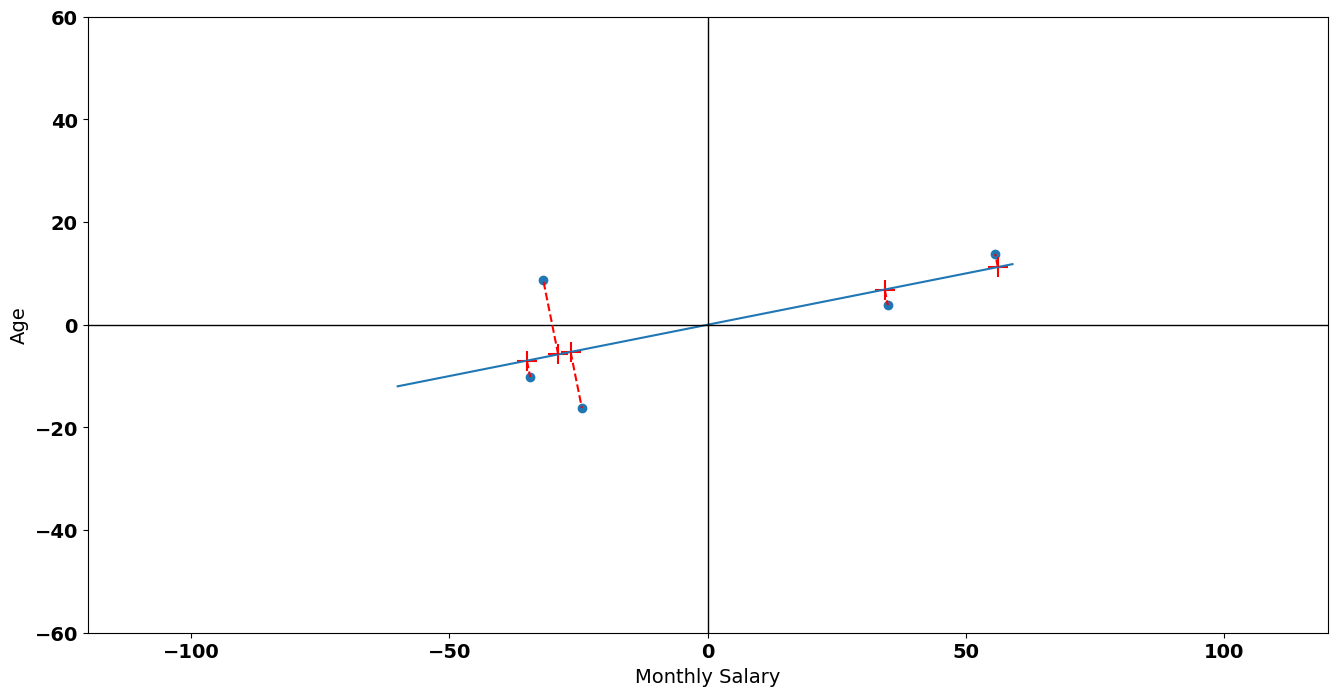

In [23]:
_ = project_points_onto_line(salary_data, 0.2)

As we are dealing with 2 principal components, `PC2` is just the perpendicular vector to `PC1`:
<br>
We can find it by solving the following equation: -1 = x*0.2 => x = -1/0.2 => -5
<br>
<br>
The slope of `PC2` is `-5`:

(-60.0, 60.0)

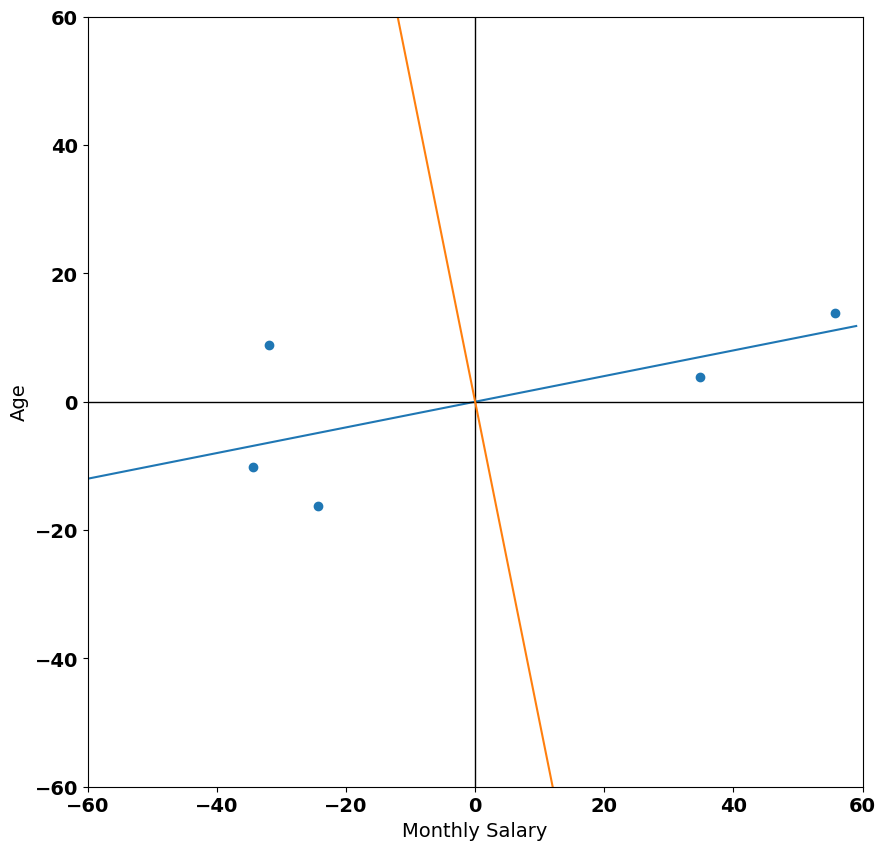

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))


scatter_with_line(salary_data, 0.2)

plt.plot(
    range(-120, 120),
    [i*-5 for i in range(-120, 120)]
)

plt.xlim(-60, 60)
plt.ylim(-60, 60)

If we rotate our plot:

In [25]:
new_points_df = rotate_points(salary_data, 0.2)

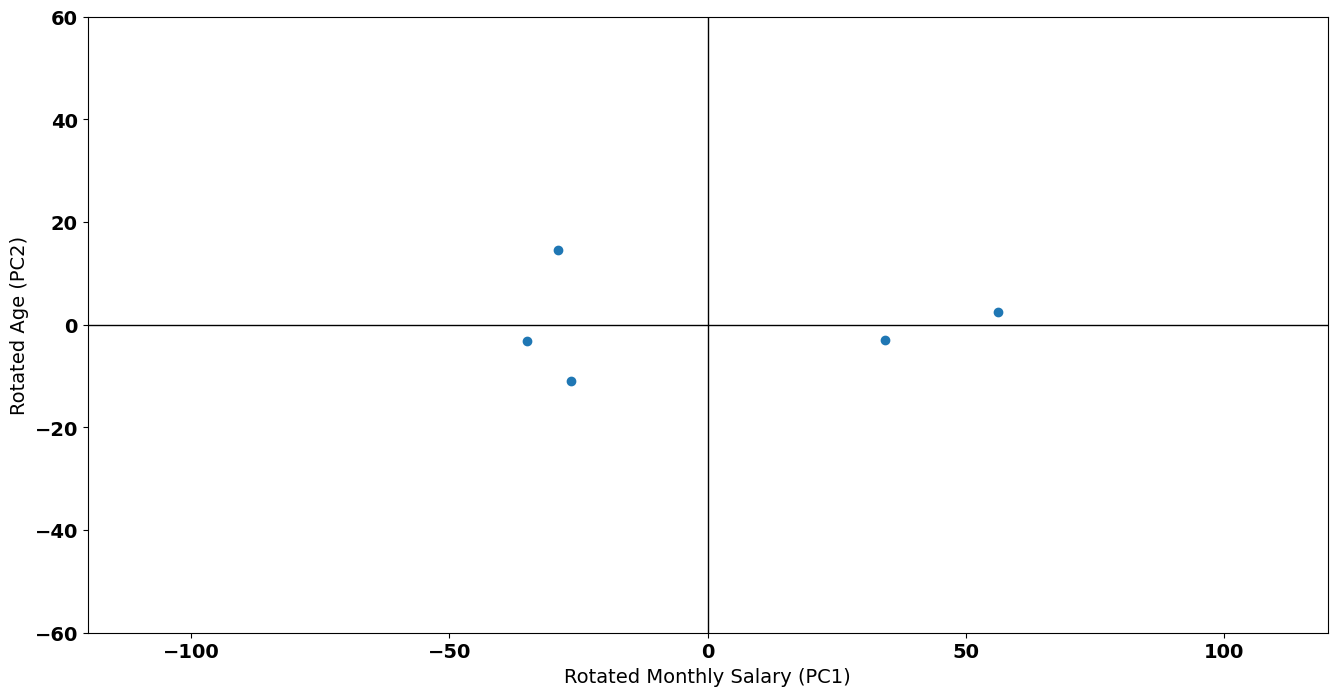

In [26]:
plt.scatter(
    new_points_df['Monthly Salary'],
    new_points_df.Age
)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.ylabel('Rotated Age (PC2)')
plt.xlabel('Rotated Monthly Salary (PC1)')

plt.xlim(-120, 120)
plt.ylim(-60, 60)
plt.show()

How can we understand which variable is more important for our principal components?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

The variation of each scatter to the origin gives us a good way to measure how each PCA accounts for the total variance:

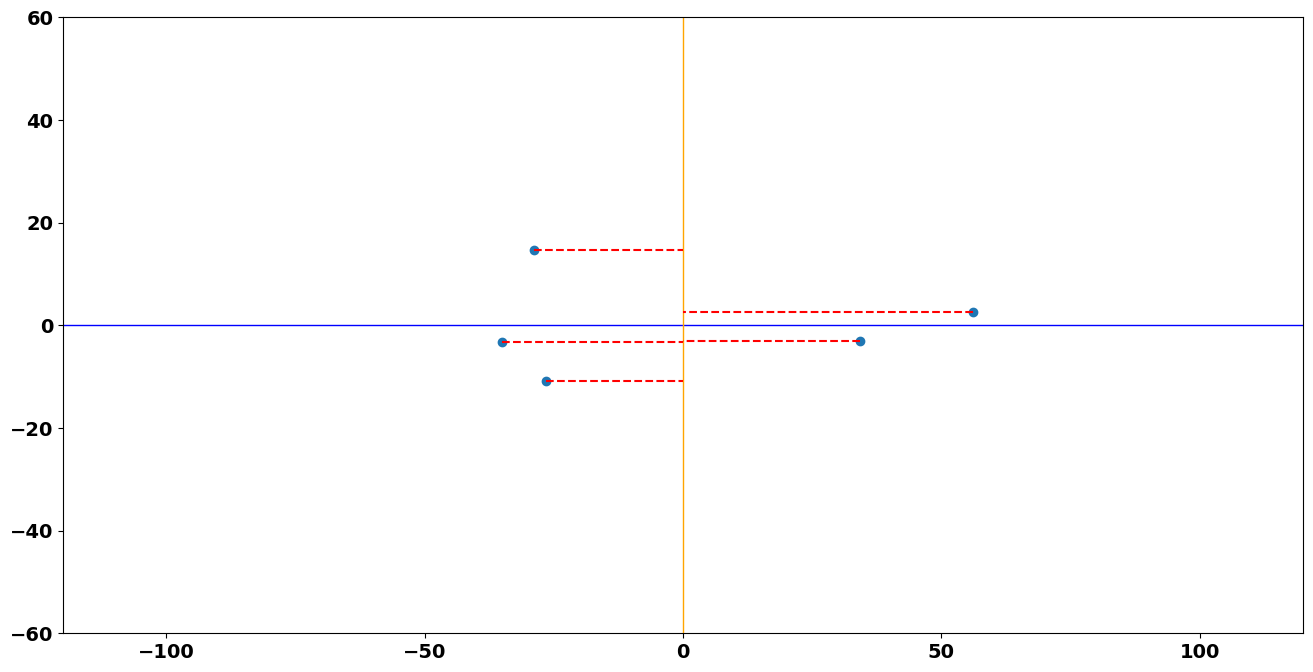

In [27]:
plt.scatter(new_points_df['Monthly Salary'], new_points_df['Age'])
plt.axhline(0, color='blue', linewidth=1)
plt.axvline(0, color='orange', linewidth=1)
plt.xlim(-120, 120)
plt.ylim(-60, 60)

for i in range(len(new_points_df)):
    plt.plot([new_points_df.iloc[i,0],0],
             [new_points_df.iloc[i,1],new_points_df.iloc[i,1]],
             '--', color='red')

We do the same reasoning for the other principal component!

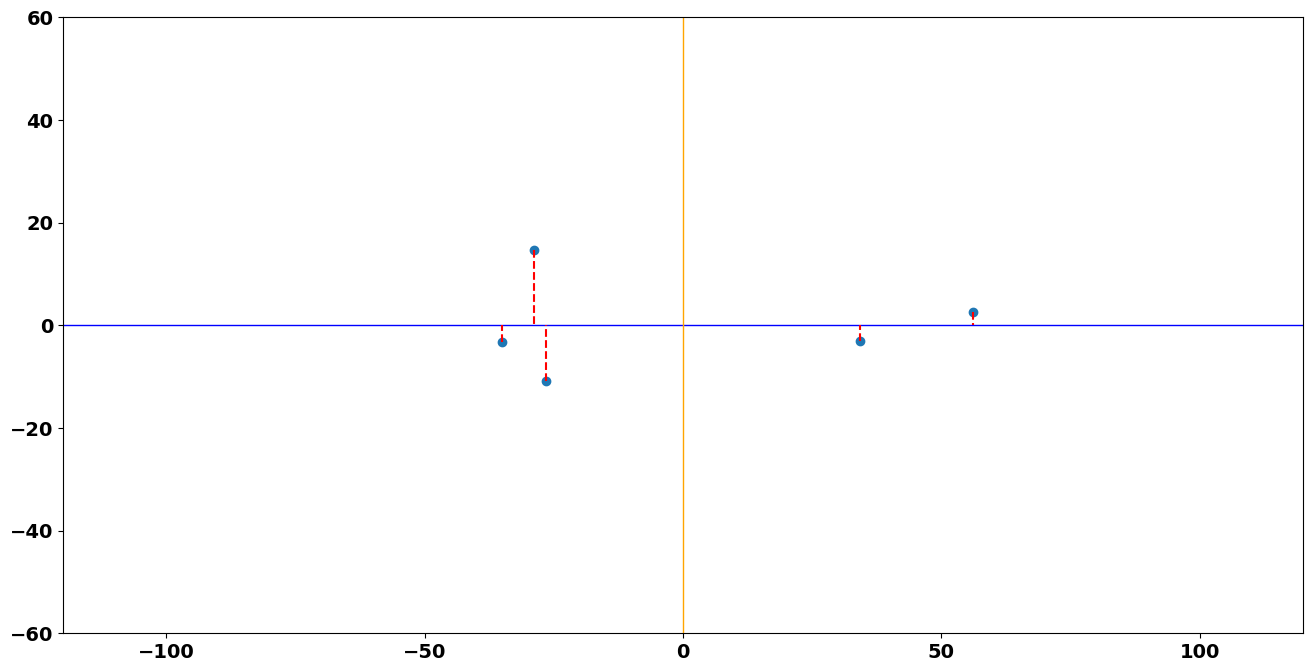

In [28]:
plt.scatter(new_points_df['Monthly Salary'], new_points_df['Age'])
plt.axhline(0, color='blue', linewidth=1)
plt.axvline(0, color='orange', linewidth=1)
plt.xlim(-120, 120)
plt.ylim(-60, 60)

for i in range(len(new_points_df)):
    plt.plot([new_points_df.iloc[i,0],new_points_df.iloc[i,0]],
             [new_points_df.iloc[i,1],0],
             '--', color='red')

Finding the total variance produced by our projected points:

In [29]:
pcs = (new_points_df**2).sum(axis=0)
pcs.index = ['PC1', 'PC2']
pcs

,0
PC1,7093.921893
PC2,357.620722


The variable "PC1" accounts for `7093` units of the variance, while PC2 only accounts for `357` units. If we divide these numbers for the total, we get a percentage:

In [30]:
pcs_perc = (new_points_df**2).sum(axis=0)/(new_points_df**2).sum().sum()
pcs_perc.index = ['PC1', 'PC2']
pcs_perc

,0
PC1,0.952007
PC2,0.047993


**Our** `PC1` accounts for 95.2% of the variance of our `PCA` solution, while `PC2` only accounts for `4.8%`. In a nutshell, just using the `PC1` variable will be enough to explain 95% of the data.

Let's confirm that all of what I said is true, by running `sklearn's` implementation!

In [31]:
from sklearn.decomposition import PCA
x = salary_data[['Monthly Salary','Age']]
pca=PCA(n_components=2)
pca.fit(x)

PCA(n_components=2)

In [32]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.95201402 0.04798598]


Nice! **Really similar what we got in our example!**

And see how the components kind of match what we found with our eigenvector:

In [33]:
pca.components_

array([[ 0.98003673,  0.1988165 ],
       [-0.1988165 ,  0.98003673]])

The goal of Principal Component Analysis is to **reduce the number of features we have on our data. This can be particularly helpful when we want to avoid the curse of dimensionality.**

Of course, we can also obtain these values using a couple of linear algebra formulas:

In [34]:
cov_matrix = np.cov(salary_data[['Monthly Salary','Age']].T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [35]:
# Redudant to choose k here, but this will help you generalize the solution
# for k top components with more features
k = 2
top_eigenvalues_index = eigenvalues.argsort()[::-1][:k]
top_eigenvectors = eigenvectors[:, top_eigenvalues_index]

In [36]:
eigenvectors.T

array([[ 0.98003673,  0.1988165 ],
       [-0.1988165 ,  0.98003673]])

In [37]:
eigenvalues

array([1844.43298208,   92.96809792])

In [38]:
eigenvalues/sum(eigenvalues)

array([0.95201402, 0.04798598])

# Practical Example (Principal Component Analysis!)

One of the most high-dimensional datasets we can think of are datasets with gene expression data.
<br>
<br>
These datasets are extremely heavy in terms of columns, as most studies contain a lot of different gene measurements that are practically impossible for a human to interpret.
<br>
<br>
In this example, we are going to use a dataset with gene expression of several brain cancer patients:

In [ ]:
# Unzip gene expression data
with zipfile.ZipFile("/content/data/brain_tumor_gene_data.zip","r") as file:
    file.extractall("/content/data/")

# Read gene expression dataset
gene_expression = pd.read_csv('/content/data/Brain_GSE50161.csv')

In [ ]:
gene_expression.head(10)

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552258_at,1552261_at,1552263_at,1552264_a_at,1552266_at,1552269_at,1552271_at,1552272_a_at,1552274_at,1552275_s_at,1552276_a_at,1552277_a_at,1552278_a_at,1552279_a_at,1552280_at,1552281_at,1552283_s_at,1552286_at,1552287_s_at,1552288_at,1552289_a_at,1552291_at,1552293_at,1552295_a_at,1552296_at,1552299_at,1552301_a_at,1552302_at,1552303_a_at,1552304_at,1552306_at,1552307_a_at,1552309_a_at,...,AFFX-HSAC07/X00351_3_at,AFFX-HSAC07/X00351_5_at,AFFX-HSAC07/X00351_M_at,AFFX-hum_alu_at,AFFX-HUMGAPDH/M33197_3_at,AFFX-HUMGAPDH/M33197_5_at,AFFX-HUMGAPDH/M33197_M_at,AFFX-HUMISGF3A/M97935_3_at,AFFX-HUMISGF3A/M97935_5_at,AFFX-HUMISGF3A/M97935_MA_at,AFFX-HUMISGF3A/M97935_MB_at,AFFX-HUMRGE/M10098_3_at,AFFX-HUMRGE/M10098_5_at,AFFX-HUMRGE/M10098_M_at,AFFX-LysX-3_at,AFFX-LysX-5_at,AFFX-LysX-M_at,AFFX-M27830_3_at,AFFX-M27830_5_at,AFFX-M27830_M_at,AFFX-PheX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-r2-Bs-dap-3_at,AFFX-r2-Bs-dap-5_at,AFFX-r2-Bs-dap-M_at,AFFX-r2-Bs-lys-3_at,AFFX-r2-Bs-lys-5_at,AFFX-r2-Bs-lys-M_at,AFFX-r2-Bs-phe-3_at,AFFX-r2-Bs-phe-5_at,AFFX-r2-Bs-phe-M_at,AFFX-r2-Bs-thr-3_s_at,AFFX-r2-Bs-thr-5_s_at,AFFX-r2-Bs-thr-M_s_at,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Ec-bioB-5_at,AFFX-r2-Ec-bioB-M_at,AFFX-r2-Ec-bioC-3_at,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,5.898355,5.513410,7.541986,7.905140,7.108117,8.386617,8.412090,6.560058,5.779307,5.596102,9.128874,6.822846,8.222273,5.965720,6.070791,6.522746,7.031419,6.514768,8.333490,6.699891,8.290555,6.330756,7.429331,8.271134,6.889821,6.789864,6.332943,6.743534,7.683195,6.725073,9.290826,7.788566,7.877083,7.160071,4.221077,5.946682,5.536782,5.456670,5.574202,6.998608,...,13.087353,12.786701,13.104597,13.798449,13.027510,12.818440,13.092592,9.104209,5.109471,8.654586,7.452986,6.286898,4.769155,4.687528,3.754204,3.896775,4.473275,8.171548,6.060622,8.841900,5.902276,3.907297,3.882678,3.890110,3.668144,3.390117,3.953972,3.529272,3.563981,4.574315,3.828851,4.483687,5.011438,5.773626,4.827817,5.877779,6.714268,6.080413,7.475681,7.086287,9.979005,9.926470,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,5.453147,6.173106,8.317030,8.269136,7.250662,9.208559,8.466202,5.822008,5.862887,5.573160,8.853524,5.855870,6.914568,6.856960,7.268411,7.805840,7.953560,7.049230,7.985905,8.285225,9.759504,5.638496,7.963333,6.503762,7.413667,8.128855,5.010720,6.483549,7.349033,6.153470,9.634164,6.207202,7.745217,6.529700,4.353829,6.219198,6.208469,7.685030,6.318321,5.850427,...,13.912946,13.532344,13.814658,14.693825,14.237459,14.207599,14.229670,10.411498,6.596325,9.264731,9.122687,6.487188,5.011087,5.125493,3.459905,3.475047,4.250283,8.026929,7.974346,9.139429,6.088559,3.955786,3.744942,3.475500,3.545111,3.288044,3.798083,3.465220,3.398081,4.279519,3.365857,3.673009,4.822057,5.048771,4.988880,7.645660,7.913366,7.398476,9.145736,9.137122,11.924749,11.215930,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416
2,836,ependymoma,13.068179,8.573674,8.647684,9.613002,4.396581,7.813101,6.007746,7.178156,8.400266,6.323471,7.661874,8.327897,7.557231,9.344553,9.161303,6.352456,5.703981,6.296894,8.912298,6.115325,6.706525,7.236168,7.062774,7.702766,7.713712,7.146639,8.958272,5.966615,8.235646,5.393936,8.168913,7.446118,7.032315,7.511554,5.241585,6.878393,7.881382,6.073385,9.478906,7.390576,6.766979,8.191684,4.113752,6.338660,5.035822,5.206248,6.836985,7.742723,...,14.378190,13.937428,14.248673,14.497449,14.402930,14.358498,14.447217,11.321259,7.055909,10.012080,9.822739,6.453939,4.549771,4.578991,3.512840,3.480678,4.

This dataset contain 54677 columns! Luckily, we can rely on our `Principal Component Analysis` to view it a bit better.

In [ ]:
# Let's subset the features to consider for the principal component analysis
gene_expression.head(10)
features = gene_expression.iloc[:,2:]

We'll fit a `Principal Component Analysis` with 25 components. Although hard to visualize, we'll see how the % of variance retained evolves throughout the different components. But first, we need to standardize our data!

In [ ]:
sc = StandardScaler()
features_sd = sc.fit_transform(features)

In [ ]:
pca = PCA(n_components=25)
pca.fit(features_sd)

PCA(n_components=25)

Revisiting the `explained_variance_ratio` attribute:

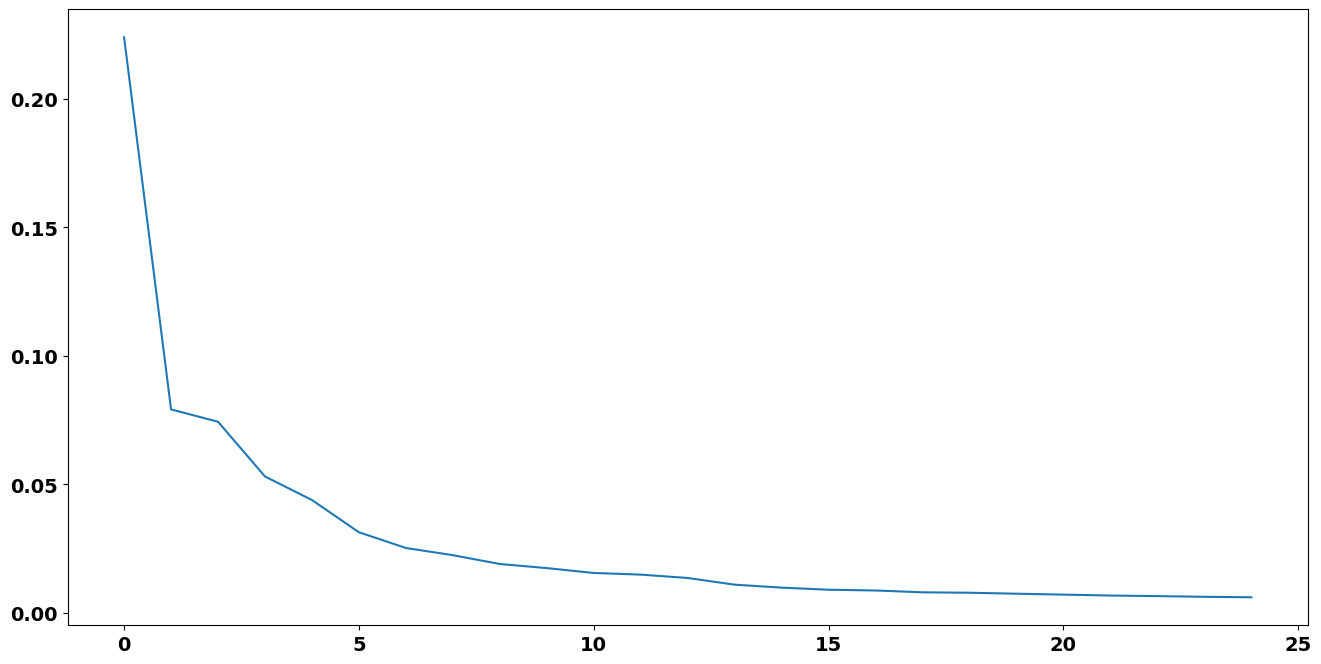

In [ ]:
plt.plot(pca.explained_variance_ratio_)

The first component explains an interesting portion of the dataset! In real life datasets, we aren't expecting that the first few components are able to explain the majority of the data (this will only happens in datasets with really high correlated features).
<br>
<br>
The most common way to see explained variance is to visualize it as a % of cumulative variance:

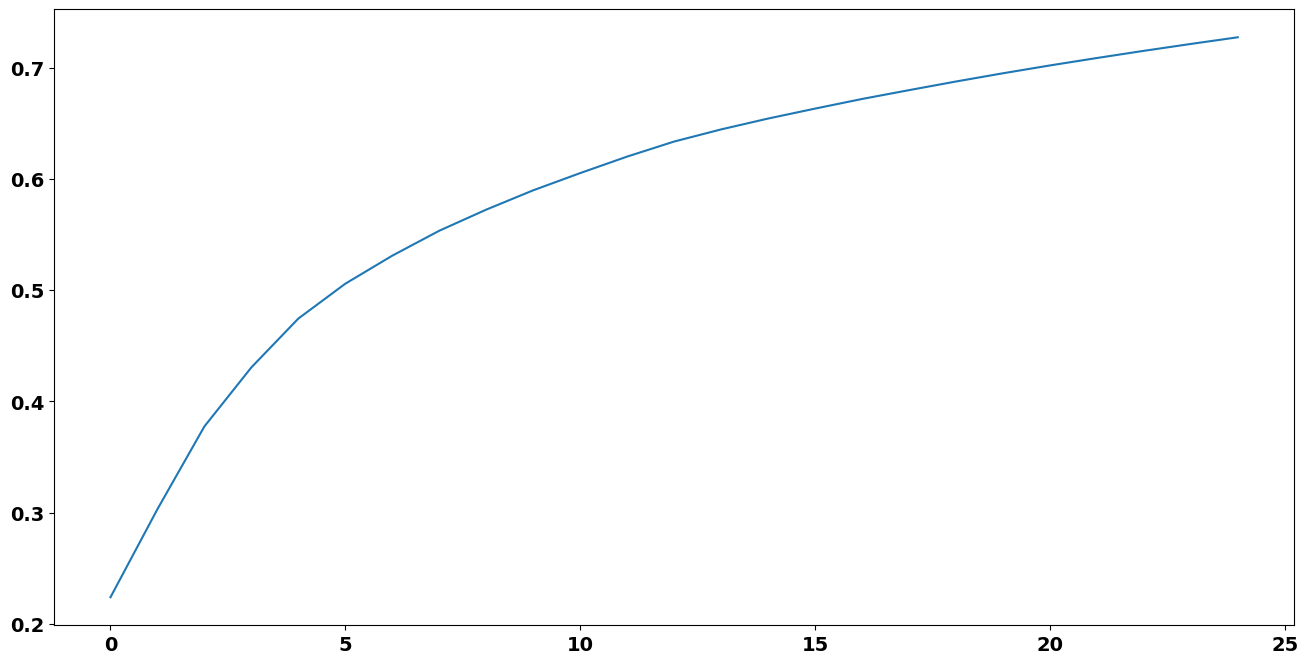

In [ ]:
plt.plot(
    pca.explained_variance_ratio_.cumsum()
)

plt.show()

Let's see the influence of each variable in our principal components:

In [ ]:
pc_variables = pd.DataFrame(
    pca.components_.T,
    columns = ['PC'+str(i) for i in range(0,25)],
    index=features.columns)

In [ ]:
pc_variables.sample(10)

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
208143_s_at,-0.002706,-0.004101,-0.001755,-0.003509,-0.004398,-0.003572,-0.002607,-0.002558,0.001665,-0.000830,0.000318,0.004068,-0.004555,0.007088,0.005175,-0.001393,0.009898,0.000481,0.001689,-0.001913,0.005256,0.005085,-0.004209,-0.004961,-0.006950
234811_at,0.002761,-0.002545,-0.000574,-0.002962,-0.003656,0.003630,0.013659,0.006816,0.000178,0.004229,-0.003550,0.004611,-0.003089,-0.005865,0.002669,0.003015,-0.002750,0.001474,0.001980,0.005414,0.002725,0.003111,0.004949,0.001575,0.003499
231580_at,-0.000128,-0.004889,-0.005305,-0.007785,-0.006215,0.003325,-0.000993,-0.000310,-0.002104,0.000642,0.007000,-0.002208,-0.000253,0.001876,-0.006114,-0.002251,-0.010050,-0.003593,0.007251,0.004741,-0.008215,-0.004949,-0.004934,-0.000833,-0.009138
218440_at,-0.006514,0.003467,-0.004048,0.003599,0.000169,-0.002197,-0.002175,0.001442,0.003324,-0.002841,-0.002441,0.001129,0.004483,-0.009093,0.003275,0.003747,-0.001160,0.001525,-0.005116,0.002973,-0.000700,0.002013,-0.001060,-0.002408,-0.004062
229575_at,-0.005085,0.003381,0.002228,-0.003295,0.000488,-0.005329,0.007824,0.004988,0.002199,-0.001266,0.004591,-0.007439,0.009104,0.002423,-0.001520,0.005197,-0.002545,0.006934,-0.000138,-0.007265,-0.004840,0.004405,0.000869,0.002252,0.002482
221882_s_at,0.000326,0.010050,-0.002148,-0.000158,-0.006416,0.007641,-0.005919,-0.002874,-0.000086,0.000118,-0.001067,0.000344,-0.002704,0.005777,-0.005482,0.002862,-0.006689,0.001506,0.001181,0.003789,-0.004028,-0.003466,-0.005632,0.000790,0.002255
215614_at,0.006542,-0.002796,0.001164,0.001901,-0.000481,-0.002937,0.000213,0.004359,-0.001344,0.000622,-0.005521,0.000964,-0.000614,0.002303,0.002131,-0.003710,0.002900,-0.005407,-0.000481,-0.000267,0.001368,0.005618,0.006574,-0.002782,-0.003776
214282_at,0.000498,0.006761,-0.003030,-0.000789,0.000527,-0.002235,0.007350,0.001351,0.001301,0.001766,-0.000923,-0.012032,0.003200,-0.000922,0.000929,-0.005291,0.005630,-0.009387,0.006405,0.001952,-0.000038,-0.001859,0.004086,-0.002734,-0.002031
223325_at,-0.004249,0.002360,-0.006202,-0.004528,0.001169,0.003612,-0.001566,0.000914,0.000656,0.006492,0.012152,-0.001885,-0.000146,0.001856,-0.002176,0.000526,0.006067,0.003963,0.010446,0.002793,-0.000101,-0.001118,0.004723,0.003778,-0.008475
236244_at,0.003134,0.002847,0.005255,-0.007189,0.007572,0.003432,-0.008031,0.001398,-0.002728,0.001881,-0.004597,0.000236,-0.001819,0.001256,-0.000325,-0.000175,-0.003420,-0.005340,0.001176,-0.002375,-0.004723,-0.008377,0.003495,0.002592,0.001639


In [ ]:
pc_variables.sort_values('PC0')

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
1569345_at,-0.008179,-0.001954,-0.001143,-0.002330,-0.001891,0.000318,0.003293,0.001410,-0.003614,0.002686,-0.006440,-0.001492,-0.001496,0.000488,-0.002599,-0.001234,0.001601,-0.000404,0.000993,0.001266,-0.002970,-0.002094,-0.000620,0.000422,-0.001153
228512_at,-0.008096,-0.000705,0.001421,0.000037,0.000594,-0.002003,0.001537,0.000367,0.002135,0.001545,-0.004998,0.002046,0.004497,0.002045,-0.000751,0.001396,-0.003324,-0.006968,-0.002063,-0.002810,-0.002176,-0.001795,0.000238,-0.003625,-0.002406
219021_at,-0.008052,-0.001594,-0.003157,-0.000646,-0.002640,0.001698,0.000417,-0.000488,0.000814,0.001420,-0.000560,0.004432,-0.000826,0.002637,-0.002316,0.002078,0.000566,-0.003850,-0.001287,-0.001557,0.002441,-0.002393,0.004013,-0.000397,0.002291
218958_at,-0.008010,-0.002674,-0.003367,-0.000879,-0.000997,-0.000709,-0.000413,0.003155,0.002289,0.000564,-0.000305,-0.001407,0.000623,-0.001195,-0.001660,-0.000553,0.001204,0.001930,0.002437,-0.002242,0.003505,0.003295,0.003383,0.000141,0.002553
229436_x_at,-0.007999,-0.001930,0.001044,0.001410,-0.002336,0.001179,0.001740,0.000431,-0.001419,0.001265,0.004257,-0.000073,-0.000168,-0.000277,-0.002781,-0.000484,0.002054,0.007302,-0.003319,0.002459,-0.002312,-0.000195,0.003331,-0.000180,0.000177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569522_at,0.008795,0.000139,0.001071,0.000505,0.000853,0.000194,-0.000942,-0.000797,-0.000838,-0.001135,0.000510,-0.000953,0.001510,-0.000230,-0.000042,-0.002978,0.002536,-0.000379,0.001543,0.000981,0.000824,0.000415,0.000612,-0.000077,-0.000502
1556507_at,0.008823,0.000281,0.000658,0.000856,0.000401,-0.000488,0.000639,-0.000807,-0.001852,0.000548,-0.000460,-0.000240,0.000490,0.001306,0.000939,-0.004793,0.000453,0.001427,-0.001483,-0.001959,0.000900,-0.001020,-0.002310,0.001426,-0.001342
1554616_at,0.008824,-0.000264,0.000240,0.000775,-0.000090,-0.002689,-0.000399,-0.000687,-0.000713,-0.001927,0.001776,0.001519,0.000698,0.001035,0.000389,-0.001684,-0.000249,-0.000919,-0.000468,-0.000611,0.000555,-0.001022,0.002115,-0.000137,-0.001157
1561171_a_at,0.008829,0.000124,0.000732,0.001203,0.000382,-0.001240,-0.001064,-0.000077,-0.000111,-0.000347,0.000308,0.000372,0.000802,0.000421,0.000772,-0.002039,-0.001018,-0.000632,-0.000220,-0.000936,0.001003,0.000372,0.000355,0.000910,0.000354


Let's grab our first two components and check (in 2-D), how well they map the classes:

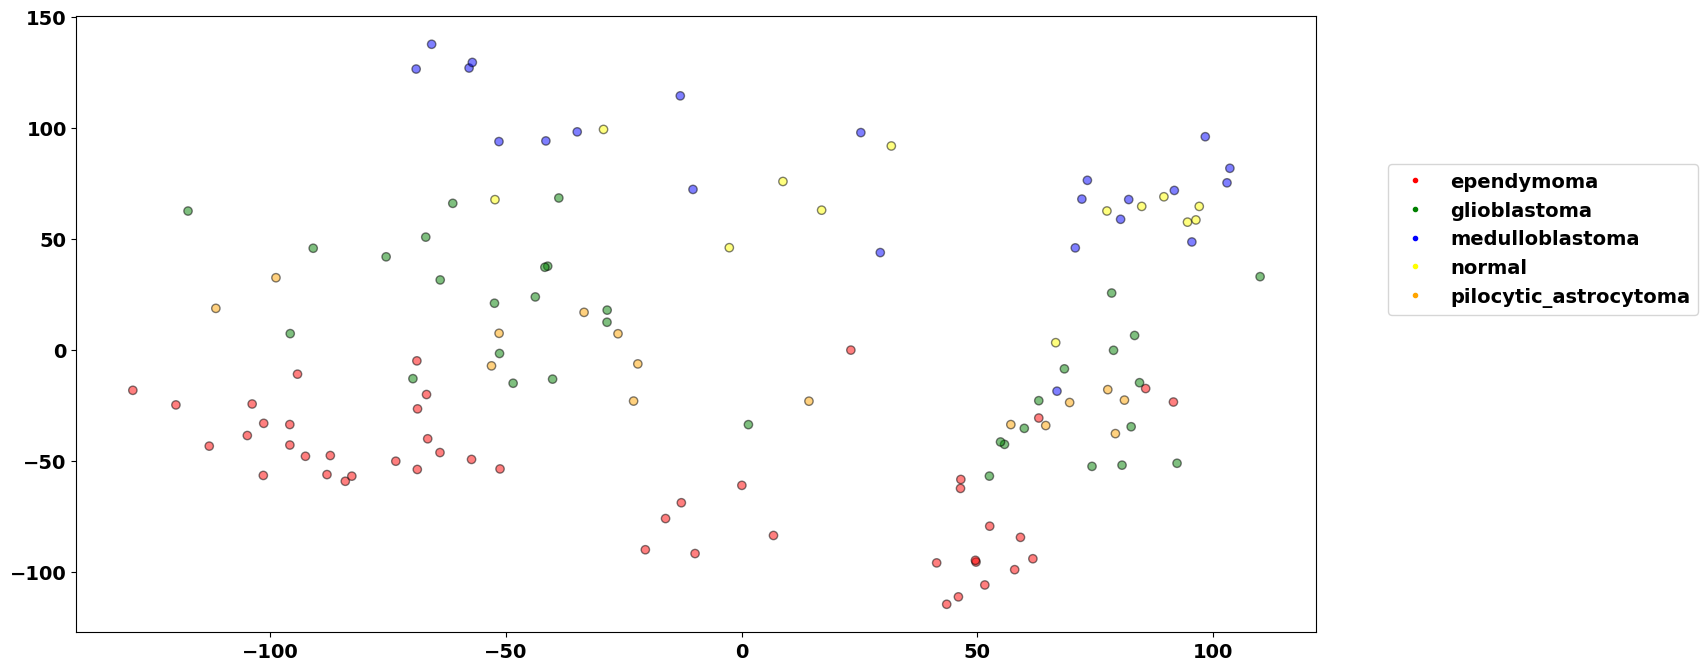

In [ ]:
first_components = pca.fit_transform(features)[:,:2]

plot_2d_with_classes(gene_expression.type, first_components)

Very interesting! Just two components (that account for, roughly, 30% of the variance) already give us a good idea of the potential of the dataset to map these classes.

One of the common things that we can do with `PCA`, is analyze the most important components - for instance, understanding how the variables interact with the value of the component:

In [ ]:
gene_expression['first_component'] = first_components[:,0]

In [ ]:
gene_expression[['38447_at', 'first_component']].corr()

,38447_at,first_component
38447_at,1.000000,-0.922788
first_component,-0.922788,1.000000


The variable 38447_at (that should correspond to a specific gene meaasurement) is highly correlated with the value of the first component. Remember that the value of the `first_component` is the projection of our data point into that axis!

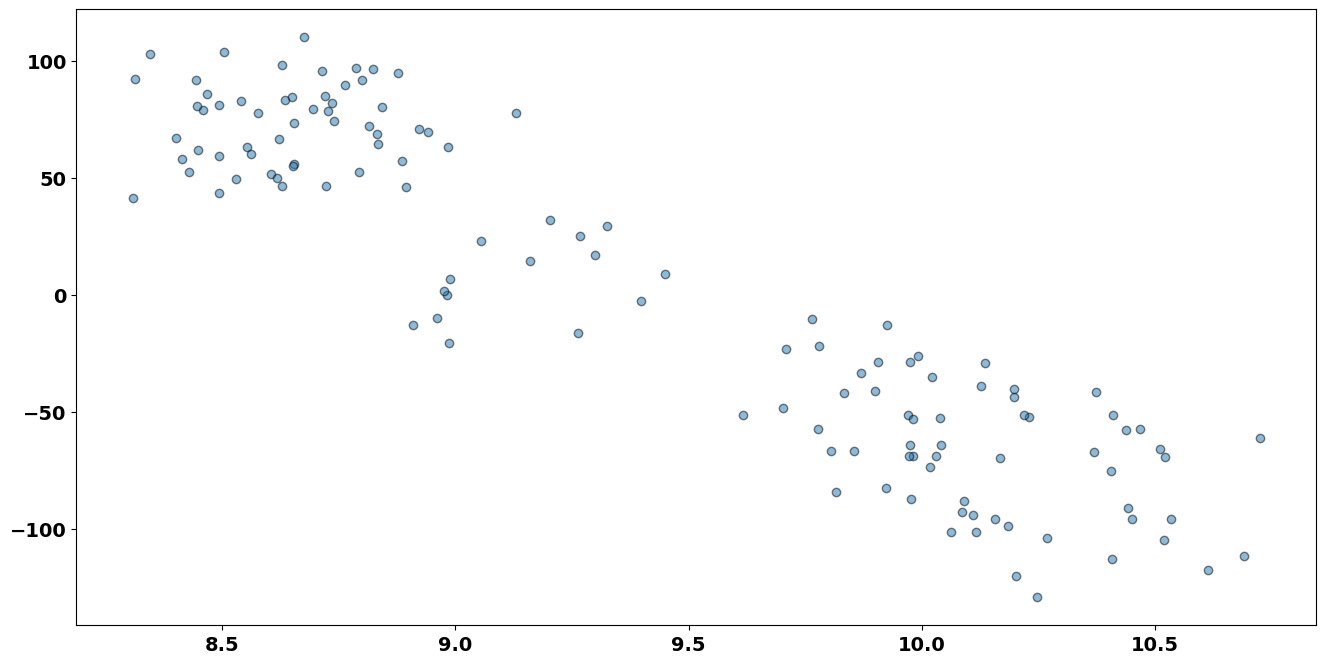

In [ ]:
scatter = plt.scatter(
    gene_expression['38447_at'],
    gene_expression.first_component,
    alpha=0.5,
    edgecolors='black'
)

On the other hand, we can also measure the evolution of an inversely correlated feature:

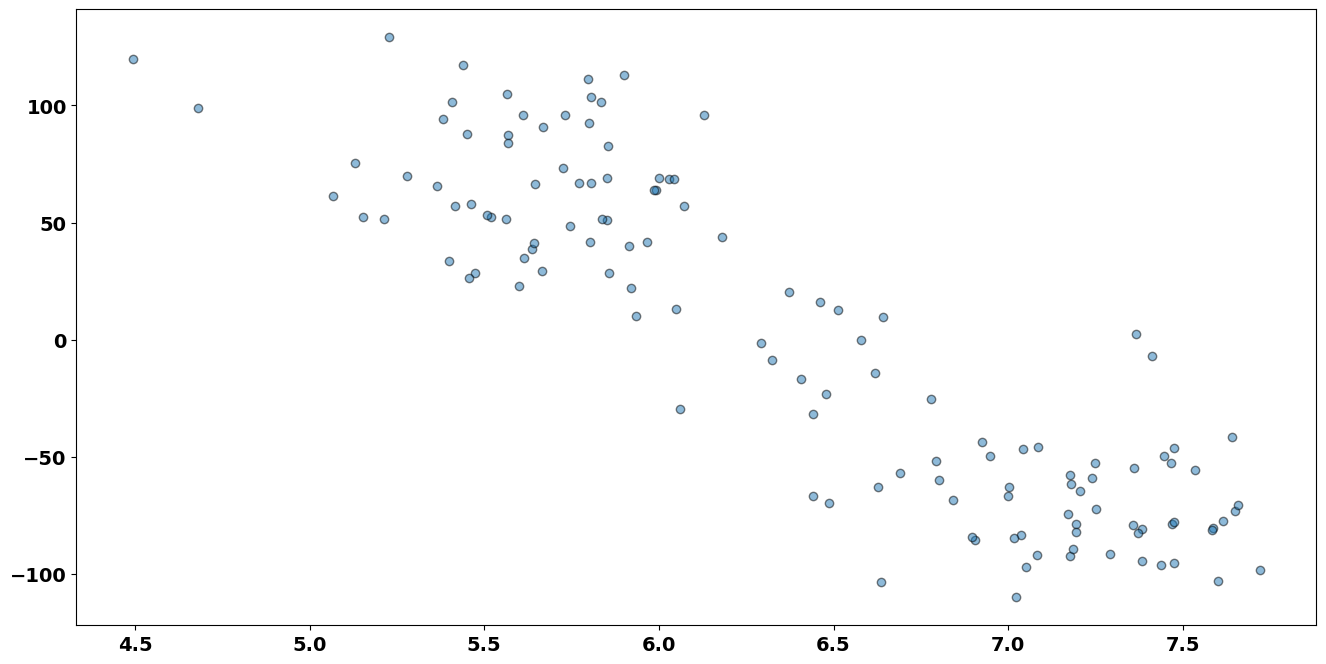

In [ ]:
scatter = plt.scatter(
    gene_expression['1569345_at'],
    gene_expression['first_component'],
    alpha=0.5,
    edgecolors='black'
)

# Exercise Section

As usual, let's practice a bit! In this exercise section we'll fit and interpret a `Principal Component Analysis`.
<br>

### Exercise 1

Load the `wine` dataset from the `url`: 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data' using `header=None`.
<br>
Save the file in a `wine_data` dataframe.
<br>
<br>
Give the following column names to the `wine_data` object:
['label', 'alcohol', 'malic_acid', 'ash', 'alcalinity', 'magnesium', 'total_phenols', 'flavanoids', 'n_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'dil_win', 'proline']

In [ ]:
### YOUR CODE HERE

### Exercise 2

Scale all variables of the wine dataset, except `label`, using a `StandardScaler`. Save the returning object in a data frame named `scaled_wine`:

In [ ]:
### YOUR CODE HERE

### Exercise 3

Apply a Principal Component Analysis with 8 components to the `scaled_wine` data. Save your trained unsupervised model in a variable called `pca_wine`.

In [ ]:
### YOUR CODE HERE

### Exercise 4

Apply your `pca_wine` object to the `scaled_wine` dataset. Save the returning object in a `components` variable:

In [ ]:
### YOUR CODE HERE

### Exercise 5

Plot the first 2 components in a 2-D scatter plot and color the data points according to the `label` column:

In [ ]:
### YOUR  CODE HERE

### Exercise 6

What is the percentage of explained variance of the first component in the `pca` solution?

In [ ]:
### YOUR  CODE HERE

-

### Exercise 7

What is the appropriate number of components to retain if we want to keep at least 70% of the original variance of the dataset?

In [ ]:
### YOUR CODE HERE

-

### Exercise 8

What variable is most influential on the 2nd component (Component Index 1) of the `pca_wine`?

In [ ]:
### YOUR CODE HERE

-

### Exercise 9

Plot the third component against the variable `alcalinity`. Color the points with the type of the wine.

In [ ]:
### YOUR CODE HERE

### Exercise 10

Based on the plot, what is the loading score for the variable `alcalinity` and the third component of our `PCA`? Do you think that the component + the variable have a chance of classifying the points accurately according to the type of wine?

-